In [1]:
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs"
data = "dream_cytof"
filename = "evaluate_all_figure1c"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)
df["N_features"] = df["N_features"] = df["features"].str.extract(r"RFE_(\d+)_permute")

In [2]:
val_df = df[df.dataset == "val"]
dmm_val_df = val_df[val_df.ref == "DMM"]
# val_df.features.fillna("None", inplace=True)
dmm_val_df.N_features = dmm_val_df.N_features.astype("int")

# Number of features

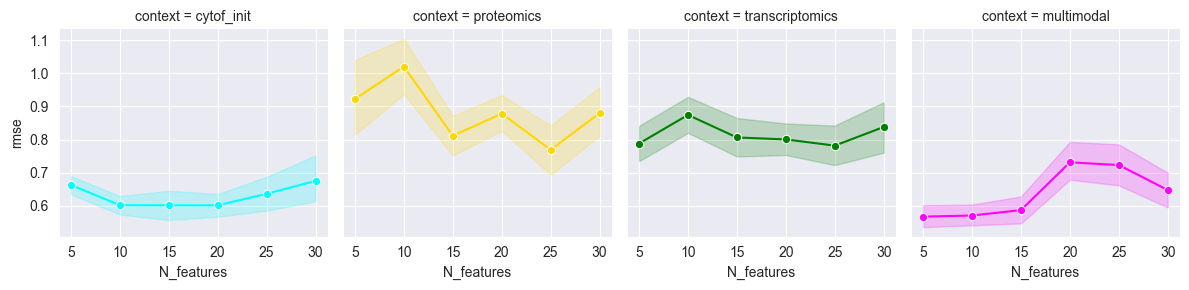

In [3]:
palette = {
    "cytof_init": "cyan",
    "proteomics": "gold",
    "transcriptomics": "green",
    "multimodal": "magenta",
}

g = sns.FacetGrid(
    dmm_val_df,
    col="context",
    col_order=palette.keys()
)

g.map_dataframe(
    sns.lineplot,
    x="N_features",
    y="rmse",
    marker='o',
    hue="context",
    palette=palette
)

In [4]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric, context_metric="context"):
    for context in df[context_metric].unique():
        context_data = df[df[context_metric] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context/Group: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

In [5]:
kruskal_wallis_groups(
    dmm_val_df[dmm_val_df.N_features >=10],
    "rmse",
    "N_features",
    "context"
)

Context/Group: proteomics - Kruskal-Wallis H-test: H-statistic=25.12, p-value=0.0000, significant? True
Context/Group: transcriptomics - Kruskal-Wallis H-test: H-statistic=8.88, p-value=0.0641, significant? False
Context/Group: multimodal - Kruskal-Wallis H-test: H-statistic=34.80, p-value=0.0000, significant? True
Context/Group: cytof_init - Kruskal-Wallis H-test: H-statistic=3.10, p-value=0.5411, significant? False


Not significant for transcriptomics. cytof_init is significant but not when N_features >= 10. multimodal only gets worse. proteomics is the only context where there seems to be an honest and significant benefit in using more features - is it just that feature selection cannot find relevant features at all and this increases the chances of finding remotely useful ones?